libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# PART A

random vectors

In [2]:
rng = np.random.default_rng()

# Data points
X = rng.random(5)
X = 5*X
X.sort()
Y = rng.random(5)
Y = 5*Y

using least squares

In [3]:
# Stack the design matrix with a column of ones (for the intercept)
A = np.vstack([X, np.ones(len(X))]).T

# Solve using least squares
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
print(f"Slope: {m}, Intercept: {c}")

Slope: 0.48612588329608547, Intercept: 1.2831025677579604


plotting

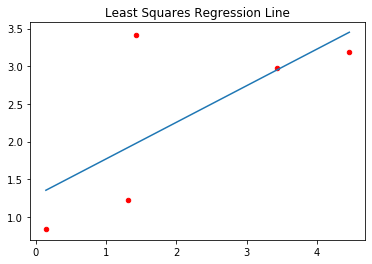

In [4]:
plt.scatter(X,Y,20,"r")
plt.plot(X,m*X+c)
plt.title("Least Squares Regression Line")
plt.show()

evaluation MSE and R-squared for least squares

In [5]:
# Mean Squared Error (MSE)
mselsq = np.mean((Y - (m*X+c))**2)
print(f'Mean Squared Error: {mselsq:.4f}')
# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - (m*X+c))**2)
r_squaredlsq = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squaredlsq:.4f}')

Mean Squared Error: 0.5777
R-squared: 0.5000


using polynomial fit (mostly copied from slides)

In [6]:
# Step 2: Polynomial fitting using NumPy's polyfit
degree = 3 # Degree of the polynomial
coefficients = np.polyfit(X, Y, degree)

# Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)

# Step 3: Use the coefficients to predict y-values (polynomial function)
# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)

# Generate predicted y-values based on the fitted polynomial
x = np.linspace(0,5,50)
y_pred = polynomial(x)

Polynomial Coefficients:  [ 0.04806474 -0.51436464  1.93155126  0.52371038]


plotting

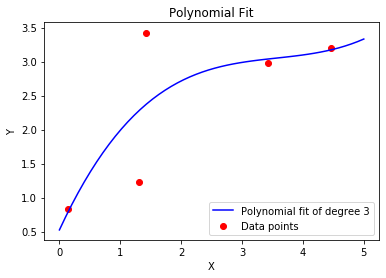

In [7]:
# Step 4: Plotting the results
plt.scatter(X, Y, color='red', label='Data points') # Original data points
plt.plot(x, y_pred, color='blue', label=f'Polynomial fit of degree {degree}')
# Fitted curve
plt.title('Polynomial Fit')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

evaluation MSE and R-squared for polynomial (cubic) fit

In [8]:
# Mean Squared Error (MSE)
msecub = np.mean((Y - polynomial(X))**2)
print(f'Mean Squared Error: {msecub:.4f}')
# R-squared value
ss_total = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - polynomial(X))**2)
r_squaredcub = 1 - (ss_res / ss_total)
print(f'R-squared: {r_squaredcub:.4f}')

Mean Squared Error: 0.4408
R-squared: 0.6185


which one is better

In [9]:
if msecub < mselsq and r_squaredcub > r_squaredlsq:
    print("Polynomial fit is the better model.")
elif mselsq < msecub and r_squaredlsq > r_squaredcub:
    print("Linear least squares is the better model.")
else:
    print("Both models perform similarly.")

Polynomial fit is the better model.
